<a href="https://colab.research.google.com/github/Zafar488/Portfolio/blob/main/PretermGuard_MODEL_3_FINAL_Industry_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MaaHifazat AI — Model 3: PretermGuard

## FINAL Industry-Level, Automatic-Download Google Colab

**PretermGuard** estimates the risk that a pregnancy will end in preterm delivery
from electrohysterogram (EHG: uterine electrical activity) summary features.

### Output

- `term`
- `preterm`
- calibrated preterm probability
- abstention / clinician-review status

### Automatically downloaded real-world datasets

1. **TPEHGDB v1.0.1 — Primary model development**
   - 300 EHG records from 300 pregnancies
   - 262 term and 38 preterm records
   - official RMS, median-frequency, peak-frequency and sample-entropy features
   - recordings around the 22nd or 32nd gestational week

2. **TPEHGT v1.0.0 — Strict external validation**
   - 13 spontaneous-preterm and 13 spontaneous-term pregnant records
   - raw EHG plus simultaneously recorded tocogram
   - separate pregnancies and a separate published dataset

3. **ICEHG v1.0.1 — Robustness / false-positive stress test**
   - 126 term EHG records from induced, cesarean, and induced-cesarean deliveries
   - verifies whether a spontaneous-delivery model incorrectly flags other term delivery modes

### Scientific design

The datasets are **not blindly concatenated**:

- TPEHGDB supplies the main supervised preterm target.
- TPEHGT is kept external and never used for threshold selection.
- ICEHG contains term delivery-mode variants and is used as a specificity stress test.
- Delivery gestation, target labels and group names are never used as model features.
- A portable feature model uses the feature family that can also be extracted from raw external EHG.

> **Medical notice:** This is a research and hackathon decision-support prototype.
> It does not diagnose preterm labour, prescribe treatment, or replace obstetric
> assessment. Prospective Pakistani hospital/device validation is mandatory.

## 1 — Install dependencies

In [1]:
%%capture
!pip install -U \
  "pandas>=2.2,<4.0" \
  "numpy>=1.26,<3.0" \
  "scipy>=1.13" \
  "matplotlib>=3.8" \
  "scikit-learn>=1.5,<2.0" \
  "xgboost>=2.1,<4.0" \
  "wfdb>=4.2" \
  "antropy>=0.1.6" \
  "requests>=2.32" \
  "joblib>=1.4" \
  "pyarrow>=16.0" \
  "fastapi>=0.115" \
  "uvicorn>=0.34" \
  "pydantic>=2.10"

## 2 — Imports, folders and reproducibility

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import random
import re
import shutil
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Mapping

import antropy as ant
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import sklearn
import wfdb
import xgboost

from scipy.signal import periodogram
from scipy.stats import randint, loguniform, uniform
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    ParameterSampler,
    StratifiedGroupKFold,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

SEED = 42
FAST_MODE = True
CV_SPLITS = 5
TUNING_ITERATIONS = 14 if FAST_MODE else 45
BOOTSTRAP_ITERATIONS = 500 if FAST_MODE else 2000
TARGET_PRETERM_RECALL = 0.90
MODEL_VERSION = "1.0.0"

np.random.seed(SEED)
random.seed(SEED)

ROOT = Path("/content/pretermguard_model_3")
RAW_DIR = ROOT / "raw"
PROCESSED_DIR = ROOT / "processed"
ARTIFACT_DIR = ROOT / "artifacts"

for directory in [RAW_DIR, PROCESSED_DIR, ARTIFACT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

EXTERNAL_STAGE_STATUS: dict[str, dict[str, Any]] = {}

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("Project root:", ROOT)

Python: 3.12.13
pandas: 3.0.3
scikit-learn: 1.9.0
XGBoost: 3.3.0
Project root: /content/pretermguard_model_3


## 3 — Dataset registry and modelling contract

In [2]:
DATASET_REGISTRY = {
    "tpehgdb": {
        "role": "primary_supervised_preterm_classifier",
        "physionet_path": "tpehgdb/1.0.1",
        "expected_records": 300,
    },
    "tpehgt": {
        "role": "strict_external_term_preterm_validation",
        "physionet_path": "tpehgt/1.0.0",
        "expected_pregnant_records": 26,
    },
    "icehg": {
        "role": "term_delivery_mode_false_positive_stress_test",
        "physionet_path": "icehg-ds/1.0.1",
        "expected_records": 126,
    },
}

TARGET_DEFINITION = {
    0: "term",
    1: "preterm",
}

print(json.dumps(DATASET_REGISTRY, indent=2))

{
  "tpehgdb": {
    "role": "primary_supervised_preterm_classifier",
    "physionet_path": "tpehgdb/1.0.1",
    "expected_records": 300
  },
  "tpehgt": {
    "role": "strict_external_term_preterm_validation",
    "physionet_path": "tpehgt/1.0.0",
    "expected_pregnant_records": 26
  },
  "icehg": {
    "role": "term_delivery_mode_false_positive_stress_test",
    "physionet_path": "icehg-ds/1.0.1",
    "expected_records": 126
  }
}


## 4 — Reliable public-file download helpers

In [3]:
def download_text(url: str, timeout: int = 120) -> str:
    response = requests.get(url, timeout=timeout)
    response.raise_for_status()
    return response.text


def stream_download(
    url: str,
    output_path: Path,
    timeout: int = 300,
) -> Path:
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists() and output_path.stat().st_size > 0:
        return output_path

    temporary_path = output_path.with_suffix(
        output_path.suffix + ".part"
    )

    with requests.get(
        url,
        stream=True,
        timeout=timeout,
    ) as response:
        response.raise_for_status()

        with temporary_path.open("wb") as file:
            for chunk in response.iter_content(
                chunk_size=1024 * 1024
            ):
                if chunk:
                    file.write(chunk)

    temporary_path.replace(output_path)
    return output_path


def download_first_available(
    urls: list[str],
    output_path: Path,
) -> Path:
    errors = []

    for url in urls:
        try:
            path = stream_download(url, output_path)
            print("Downloaded:", url)
            return path
        except Exception as error:
            errors.append({
                "url": url,
                "error": repr(error),
            })

    raise RuntimeError(
        "None of the candidate URLs could be downloaded: "
        + json.dumps(errors, indent=2)
    )


def read_physionet_records(base_url: str) -> list[str]:
    text = download_text(f"{base_url}/RECORDS")

    records = []

    for line in text.splitlines():
        value = line.strip()

        if (
            not value
            or value.startswith("#")
        ):
            continue

        value = re.sub(
            r"\.(hea|dat|atr|edf)$",
            "",
            value,
            flags=re.IGNORECASE,
        )
        records.append(value)

    return sorted(set(records))

## 5 — Download official TPEHGDB feature-value files

The notebook downloads the small official `.fvl` feature tables instead of the
full 245 MB raw primary database. This makes the primary workflow fast,
reproducible and aligned with the published feature definitions.

In [4]:
TPEHG_BASE_URL = (
    "https://physionet.org/files/"
    "tpehgdb/1.0.1"
)

FILTER_FILES = {
    "f008_4": "tpehgdb_features__filter_0.08_Hz-4.0_Hz.fvl",
    "f03_3": "tpehgdb_features__filter_0.3_Hz-3.0_Hz.fvl",
    "f03_4": "tpehgdb_features__filter_0.3_Hz-4.0_Hz.fvl",
}

fvl_paths = {}

for filter_name, filename in FILTER_FILES.items():
    fvl_paths[filter_name] = download_first_available(
        urls=[
            f"{TPEHG_BASE_URL}/{filename}",
            f"{TPEHG_BASE_URL}/tpehgdb/{filename}",
        ],
        output_path=RAW_DIR / filename,
    )

print("Downloaded feature files:", fvl_paths)

Downloaded: https://physionet.org/files/tpehgdb/1.0.1/tpehgdb_features__filter_0.08_Hz-4.0_Hz.fvl
Downloaded: https://physionet.org/files/tpehgdb/1.0.1/tpehgdb_features__filter_0.3_Hz-3.0_Hz.fvl
Downloaded: https://physionet.org/files/tpehgdb/1.0.1/tpehgdb_features__filter_0.3_Hz-4.0_Hz.fvl
Downloaded feature files: {'f008_4': PosixPath('/content/pretermguard_model_3/raw/tpehgdb_features__filter_0.08_Hz-4.0_Hz.fvl'), 'f03_3': PosixPath('/content/pretermguard_model_3/raw/tpehgdb_features__filter_0.3_Hz-3.0_Hz.fvl'), 'f03_4': PosixPath('/content/pretermguard_model_3/raw/tpehgdb_features__filter_0.3_Hz-4.0_Hz.fvl')}


## 6 — Fail-safe parser for official `.fvl` files

In [7]:
FVL_COLUMNS = [
    "record",
    "channel",
    "delivery_gestation",
    "recording_gestation",
    "group",
    "rms",
    "fmed",
    "fpeak",
    "sampen",
    "premature",
    "early",
]


def parse_boolean_token(value: Any) -> float:
    text = str(value).strip().lower()

    if text in {"t", "true", "1", "yes", "y"}:
        return 1.0
    if text in {"f", "false", "0", "no", "n"}:
        return 0.0

    return np.nan


def parse_fvl_file(
    path: Path,
    filter_name: str,
) -> pd.DataFrame:
    rows = []
    rejected_lines = []

    with path.open(
        "r",
        encoding="utf-8",
        errors="ignore",
    ) as file:
        for line_number, raw_line in enumerate(
            file,
            start=1,
        ):
            line = raw_line.strip()

            if (
                not line
                or line.startswith("#")
                or line.startswith("%")
            ):
                continue

            # Replace '|' with spaces to ensure correct tokenization
            tokens = re.split(r"\s+", line.replace("|", " "))

            if len(tokens) < 11:
                rejected_lines.append({
                    "line_number": line_number,
                    "line": line,
                    "reason": "fewer_than_11_tokens",
                })
                continue

            # Skip textual header lines.
            try:
                channel = int(float(tokens[1]))
                delivery_gestation = float(tokens[2])
                recording_gestation = float(tokens[3])
                rms = float(tokens[5])
                fmed = float(tokens[6])
                fpeak = float(tokens[7])
                sampen = float(tokens[8])
            except (TypeError, ValueError) as e:
                rejected_lines.append({
                    "line_number": line_number,
                    "line": line,
                    "reason": f"Numeric conversion error: {type(e).__name__} - {e}"
                })
                continue

            rows.append({
                "record": str(tokens[0]).strip(),
                "channel": channel,
                "delivery_gestation": delivery_gestation,
                "recording_gestation": recording_gestation,
                "group": str(tokens[4]).strip(),
                "rms": rms,
                "fmed": fmed,
                "fpeak": fpeak,
                "sampen": sampen,
                "premature": parse_boolean_token(tokens[9]),
                "early": parse_boolean_token(tokens[10]),
                "filter_name": filter_name,
            })

    frame = pd.DataFrame(rows)

    if frame.empty:
        raise RuntimeError(
            f"No usable rows were parsed from {path.name}. "
            f"Rejected examples: {rejected_lines[:3]}"
        )

    if frame["channel"].nunique() < 3:
        raise RuntimeError(
            f"{path.name} contains fewer than three EHG channels."
        )

    return frame


parsed_fvl_frames = [
    parse_fvl_file(path, filter_name)
    for filter_name, path in fvl_paths.items()
]

tpehg_long = pd.concat(
    parsed_fvl_frames,
    ignore_index=True,
)

print("Parsed long-table shape:", tpehg_long.shape)
display(tpehg_long.head())

Parsed long-table shape: (2700, 12)


,record,channel,delivery_gestation,recording_gestation,group,rms,fmed,fpeak,sampen,premature,early,filter_name
0,tpehg1007,1,35.00,31.29,>=26-PRE,27.9148,0.3109,0.3159,0.502,1.0,0.0,f008_4
1,tpehg1007,2,35.00,31.29,>=26-PRE,30.2607,0.2966,0.3045,0.328,1.0,0.0,f008_4
2,tpehg1007,3,35.00,31.29,>=26-PRE,18.9435,0.2037,0.2938,0.444,1.0,0.0,f008_4
3,tpehg1021,1,38.57,22.29,<26-TERM,54.2390,0.1426,0.1126,0.243,0.0,1.0,f008_4
4,tpehg1021,2,38.57,22.29,<26-TERM,40.4809,0.1440,0.1012,0.262,0.0,1.0,f008_4


## 7 — Parser unit test

In [8]:
synthetic_fvl = RAW_DIR / "_synthetic_parser_test.fvl"

synthetic_fvl.write_text(
    "Record Chann Gestation RecTime Group RMS Fmed Fpeak SampEn Premature Early\n"
    "tpehg1001 1 39.0 23.0 E-TERM 0.10 0.30 0.25 0.80 f t\n"
    "tpehg1001 2 39.0 23.0 E-TERM 0.20 0.31 0.26 0.81 f t\n"
    "tpehg1001 3 39.0 23.0 E-TERM 0.30 0.32 0.27 0.82 f t\n",
    encoding="utf-8",
)

synthetic_result = parse_fvl_file(
    synthetic_fvl,
    "test_filter",
)

assert len(synthetic_result) == 3
assert synthetic_result["channel"].tolist() == [1, 2, 3]
assert synthetic_result["premature"].eq(0).all()

synthetic_fvl.unlink(missing_ok=True)

print("FVL parser unit test passed.")

FVL parser unit test passed.


## 8 — Build one leakage-safe row per pregnancy

`delivery_gestation`, `group`, `premature`, and any value derived from delivery
timing are target/label fields. They are retained for auditing but excluded from
the model feature matrix.

In [9]:
signal_features = [
    "rms",
    "fmed",
    "fpeak",
    "sampen",
]

wide_parts = []

for filter_name in FILTER_FILES:
    filter_frame = tpehg_long[
        tpehg_long["filter_name"] == filter_name
    ].copy()

    pivoted = filter_frame.pivot_table(
        index="record",
        columns="channel",
        values=signal_features,
        aggfunc="first",
    )

    pivoted.columns = [
        f"{filter_name}_ch{channel}_{feature}"
        for feature, channel in pivoted.columns
    ]

    wide_parts.append(pivoted)

clinical_audit = (
    tpehg_long
    .sort_values(["record", "filter_name", "channel"])
    .groupby("record", as_index=True)
    .agg(
        delivery_gestation=("delivery_gestation", "first"),
        recording_gestation=("recording_gestation", "first"),
        group=("group", "first"),
        premature=("premature", "first"),
        early=("early", "first"),
    )
)

primary_data = clinical_audit.join(
    wide_parts,
    how="inner",
).reset_index()

primary_data["target"] = (
    primary_data["premature"]
    .astype(int)
)

FULL_SIGNAL_FEATURES = [
    column
    for column in primary_data.columns
    if re.match(
        r"^f(008_4|03_3|03_4)_ch[123]_(rms|fmed|fpeak|sampen)$",
        column,
    )
]

MODEL_FEATURES = [
    "recording_gestation",
    *FULL_SIGNAL_FEATURES,
]

PORTABLE_FEATURES = [
    "recording_gestation",
    *[
        column
        for column in FULL_SIGNAL_FEATURES
        if column.startswith("f008_4_")
    ],
]

print("Primary records:", len(primary_data))
print("Target distribution:")
display(
    primary_data["target"]
    .map(TARGET_DEFINITION)
    .value_counts()
    .to_frame("count")
)
print("Full model features:", len(MODEL_FEATURES))
print("Portable model features:", len(PORTABLE_FEATURES))

if len(primary_data) != 300:
    raise RuntimeError(
        f"Expected 300 primary records, found {len(primary_data)}."
    )

if primary_data["target"].sum() < 30:
    raise RuntimeError(
        "Too few preterm labels were parsed."
    )

Primary records: 300
Target distribution:


,count
target,
term,262
preterm,38


Full model features: 37
Portable model features: 13


## 9 — Data-quality and leakage audit

In [10]:
quality_report = {
    "records": int(len(primary_data)),
    "unique_record_ids": int(primary_data["record"].nunique()),
    "preterm_records": int(primary_data["target"].sum()),
    "term_records": int((primary_data["target"] == 0).sum()),
    "duplicate_record_ids": int(primary_data["record"].duplicated().sum()),
    "missing_by_feature": (
        primary_data[MODEL_FEATURES]
        .isna()
        .sum()
        .astype(int)
        .to_dict()
    ),
    "excluded_leakage_fields": [
        "delivery_gestation",
        "group",
        "premature",
        "early",
    ],
}

if primary_data["record"].duplicated().any():
    raise RuntimeError("Duplicate pregnancy record IDs detected.")

print(json.dumps(quality_report, indent=2))

primary_data.to_parquet(
    PROCESSED_DIR / "tpehgdb_primary_features.parquet",
    index=False,
)

with open(
    ARTIFACT_DIR / "primary_data_quality.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(quality_report, file, indent=2)

{
  "records": 300,
  "unique_record_ids": 300,
  "preterm_records": 38,
  "term_records": 262,
  "duplicate_record_ids": 0,
  "missing_by_feature": {
    "recording_gestation": 0,
    "f008_4_ch1_fmed": 0,
    "f008_4_ch2_fmed": 0,
    "f008_4_ch3_fmed": 0,
    "f008_4_ch1_fpeak": 0,
    "f008_4_ch2_fpeak": 0,
    "f008_4_ch3_fpeak": 0,
    "f008_4_ch1_rms": 0,
    "f008_4_ch2_rms": 0,
    "f008_4_ch3_rms": 0,
    "f008_4_ch1_sampen": 0,
    "f008_4_ch2_sampen": 0,
    "f008_4_ch3_sampen": 0,
    "f03_3_ch1_fmed": 0,
    "f03_3_ch2_fmed": 0,
    "f03_3_ch3_fmed": 0,
    "f03_3_ch1_fpeak": 0,
    "f03_3_ch2_fpeak": 0,
    "f03_3_ch3_fpeak": 0,
    "f03_3_ch1_rms": 0,
    "f03_3_ch2_rms": 0,
    "f03_3_ch3_rms": 0,
    "f03_3_ch1_sampen": 0,
    "f03_3_ch2_sampen": 0,
    "f03_3_ch3_sampen": 0,
    "f03_4_ch1_fmed": 0,
    "f03_4_ch2_fmed": 0,
    "f03_4_ch3_fmed": 0,
    "f03_4_ch1_fpeak": 0,
    "f03_4_ch2_fpeak": 0,
    "f03_4_ch3_fpeak": 0,
    "f03_4_ch1_rms": 0,
    "f03_4_ch2_rms

## 10 — Class-balanced sample weights

In [11]:
def calculate_class_weights(
    targets: pd.Series,
) -> np.ndarray:
    targets = targets.reset_index(drop=True)
    counts = targets.value_counts()

    weights = targets.map(
        lambda value: 1.0 / float(counts.loc[value])
    ).to_numpy(dtype=float)

    return weights / weights.mean()


all_weights = calculate_class_weights(
    primary_data["target"]
)

weight_audit = pd.DataFrame({
    "target": primary_data["target"],
    "weight": all_weights,
}).groupby("target").agg(
    rows=("weight", "size"),
    total_weight=("weight", "sum"),
    mean_weight=("weight", "mean"),
)

weight_audit.index = weight_audit.index.map(
    TARGET_DEFINITION
)

display(weight_audit)

,rows,total_weight,mean_weight
target,,,
term,262,150.0,0.572519
preterm,38,150.0,3.947368


## 11 — Group-safe held-out test split

In [12]:
X_all = primary_data[MODEL_FEATURES].copy()
y_all = primary_data["target"].copy()
groups_all = primary_data["record"].copy()

outer_splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

train_indices, test_indices = next(
    outer_splitter.split(
        X_all,
        y_all,
        groups=groups_all,
    )
)

X_train = X_all.iloc[train_indices].reset_index(drop=True)
X_test = X_all.iloc[test_indices].reset_index(drop=True)
y_train = y_all.iloc[train_indices].reset_index(drop=True)
y_test = y_all.iloc[test_indices].reset_index(drop=True)
groups_train = groups_all.iloc[train_indices].reset_index(drop=True)
groups_test = groups_all.iloc[test_indices].reset_index(drop=True)

assert set(groups_train).isdisjoint(set(groups_test))

split_summary = pd.DataFrame({
    "train": y_train.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index(),
})
split_summary.index = split_summary.index.map(
    TARGET_DEFINITION
)

display(split_summary)
print("Training rows:", len(X_train))
print("Held-out rows:", len(X_test))

,train,test
target,,
term,210,52
preterm,30,8


Training rows: 240
Held-out rows: 60


## 12 — Candidate models

In [13]:
linear_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", RobustScaler()),
])

tree_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
])

CANDIDATE_MODELS = {
    "logistic_regression": Pipeline([
        ("preprocess", linear_preprocessor),
        ("model", LogisticRegression(
            C=1.0,
            max_iter=5000,
            random_state=SEED,
        )),
    ]),
    "random_forest": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=600,
            min_samples_leaf=2,
            random_state=SEED,
            n_jobs=1,
        )),
    ]),
    "extra_trees": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", ExtraTreesClassifier(
            n_estimators=600,
            min_samples_leaf=2,
            random_state=SEED,
            n_jobs=1,
        )),
    ]),
    "xgboost": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            n_estimators=500,
            max_depth=3,
            learning_rate=0.03,
            min_child_weight=2,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.01,
            reg_lambda=3.0,
            random_state=SEED,
            tree_method="hist",
            n_jobs=1,
        )),
    ]),
}

print("Candidate models:", list(CANDIDATE_MODELS))

Candidate models: ['logistic_regression', 'random_forest', 'extra_trees', 'xgboost']


## 13 — Safety-focused metrics

In [14]:
def preterm_recall(
    y_true,
    predictions,
    sample_weight=None,
) -> float:
    return recall_score(
        y_true,
        predictions,
        pos_label=1,
        sample_weight=sample_weight,
        zero_division=0,
    )


def preterm_precision(
    y_true,
    predictions,
    sample_weight=None,
) -> float:
    return precision_score(
        y_true,
        predictions,
        pos_label=1,
        sample_weight=sample_weight,
        zero_division=0,
    )


def safety_score(
    y_true,
    predictions,
    sample_weight=None,
) -> float:
    recall = preterm_recall(
        y_true,
        predictions,
        sample_weight,
    )
    macro_f1 = f1_score(
        y_true,
        predictions,
        average="macro",
        sample_weight=sample_weight,
        zero_division=0,
    )
    balanced = balanced_accuracy_score(
        y_true,
        predictions,
        sample_weight=sample_weight,
    )

    return (
        0.60 * recall
        + 0.25 * macro_f1
        + 0.15 * balanced
    )


def binary_metrics(
    y_true,
    predictions,
    probabilities,
    sample_weight=None,
) -> dict[str, float]:
    return {
        "safety": safety_score(
            y_true,
            predictions,
            sample_weight,
        ),
        "accuracy": accuracy_score(
            y_true,
            predictions,
            sample_weight=sample_weight,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            predictions,
            sample_weight=sample_weight,
        ),
        "macro_f1": f1_score(
            y_true,
            predictions,
            average="macro",
            sample_weight=sample_weight,
            zero_division=0,
        ),
        "preterm_recall": preterm_recall(
            y_true,
            predictions,
            sample_weight,
        ),
        "preterm_precision": preterm_precision(
            y_true,
            predictions,
            sample_weight,
        ),
        "roc_auc": roc_auc_score(
            y_true,
            probabilities,
            sample_weight=sample_weight,
        ),
        "average_precision": average_precision_score(
            y_true,
            probabilities,
            sample_weight=sample_weight,
        ),
        "log_loss": log_loss(
            y_true,
            probabilities,
            labels=[0, 1],
            sample_weight=sample_weight,
        ),
    }

## 14 — Shared weighted cross-validation evaluator

In [15]:
inner_splitter = StratifiedGroupKFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=SEED,
)

CV_SPLITS_LIST = list(
    inner_splitter.split(
        X_train,
        y_train,
        groups=groups_train,
    )
)


def fit_weighted_model(
    estimator: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
) -> Pipeline:
    model = clone(estimator)
    weights = calculate_class_weights(y)

    model.fit(
        X,
        y,
        model__sample_weight=weights,
    )

    return model


def evaluate_cv(
    estimator: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
    splits: list[tuple[np.ndarray, np.ndarray]],
) -> pd.DataFrame:
    rows = []

    for fold, (fit_idx, validation_idx) in enumerate(
        splits,
        start=1,
    ):
        model = fit_weighted_model(
            estimator,
            X.iloc[fit_idx],
            y.iloc[fit_idx],
        )

        probabilities = model.predict_proba(
            X.iloc[validation_idx]
        )[:, 1]
        predictions = (
            probabilities >= 0.5
        ).astype(int)

        validation_weights = calculate_class_weights(
            y.iloc[validation_idx]
        )

        metrics = binary_metrics(
            y.iloc[validation_idx],
            predictions,
            probabilities,
            validation_weights,
        )
        metrics["fold"] = fold
        rows.append(metrics)

    return pd.DataFrame(rows)

## 15 — Baseline model benchmark

In [16]:
benchmark_rows = []
baseline_fold_reports = {}

for model_name, estimator in CANDIDATE_MODELS.items():
    print("Evaluating:", model_name)

    fold_report = evaluate_cv(
        estimator,
        X_train,
        y_train,
        CV_SPLITS_LIST,
    )
    baseline_fold_reports[model_name] = fold_report

    benchmark_rows.append({
        "model": model_name,
        "mean_safety": fold_report["safety"].mean(),
        "std_safety": fold_report["safety"].std(),
        "mean_average_precision": (
            fold_report["average_precision"].mean()
        ),
        "mean_roc_auc": fold_report["roc_auc"].mean(),
        "mean_balanced_accuracy": (
            fold_report["balanced_accuracy"].mean()
        ),
        "mean_macro_f1": fold_report["macro_f1"].mean(),
        "mean_preterm_recall": (
            fold_report["preterm_recall"].mean()
        ),
        "mean_preterm_precision": (
            fold_report["preterm_precision"].mean()
        ),
    })

benchmark = (
    pd.DataFrame(benchmark_rows)
    .sort_values(
        ["mean_safety", "mean_average_precision"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(benchmark.round(4))

benchmark.to_csv(
    ARTIFACT_DIR / "primary_model_benchmark.csv",
    index=False,
)

for model_name, report in baseline_fold_reports.items():
    report.to_csv(
        ARTIFACT_DIR / f"cv_{model_name}.csv",
        index=False,
    )

Evaluating: logistic_regression
Evaluating: random_forest
Evaluating: extra_trees
Evaluating: xgboost


,model,mean_safety,std_safety,mean_average_precision,mean_roc_auc,mean_balanced_accuracy,mean_macro_f1,mean_preterm_recall,mean_preterm_precision
0,logistic_regression,0.3808,0.0532,0.6116,0.5611,0.5190,0.4917,0.3000,0.5397
1,random_forest,0.2725,0.0660,0.6521,0.6143,0.5405,0.4456,0.1333,0.6189
2,xgboost,0.2104,0.0803,0.6189,0.5373,0.5024,0.3802,0.0667,0.2827
3,extra_trees,0.1583,0.0000,0.6602,0.6413,0.5000,0.3333,0.0000,0.0000


## 16 — Custom weighted hyperparameter tuning

In [17]:
best_family = str(
    benchmark.iloc[0]["model"]
)
base_estimator = CANDIDATE_MODELS[
    best_family
]

PARAMETER_SPACES = {
    "logistic_regression": {
        "model__C": loguniform(1e-3, 1e2),
    },
    "random_forest": {
        "model__n_estimators": randint(350, 1001),
        "model__max_depth": [None, 4, 6, 8, 12, 16],
        "model__min_samples_split": randint(2, 18),
        "model__min_samples_leaf": randint(1, 10),
        "model__max_features": ["sqrt", "log2", 0.6, 0.8, None],
    },
    "extra_trees": {
        "model__n_estimators": randint(350, 1001),
        "model__max_depth": [None, 4, 6, 8, 12, 16],
        "model__min_samples_split": randint(2, 18),
        "model__min_samples_leaf": randint(1, 10),
        "model__max_features": ["sqrt", "log2", 0.6, 0.8, None],
    },
    "xgboost": {
        "model__n_estimators": randint(250, 901),
        "model__max_depth": randint(2, 7),
        "model__learning_rate": loguniform(0.01, 0.15),
        "model__min_child_weight": randint(1, 10),
        "model__subsample": uniform(0.65, 0.35),
        "model__colsample_bytree": uniform(0.65, 0.35),
        "model__reg_alpha": loguniform(1e-5, 2.0),
        "model__reg_lambda": loguniform(0.1, 15.0),
        "model__gamma": uniform(0.0, 1.0),
    },
}

parameter_candidates = list(
    ParameterSampler(
        PARAMETER_SPACES[best_family],
        n_iter=TUNING_ITERATIONS,
        random_state=SEED,
    )
)

tuning_rows = []

for candidate_number, parameters in enumerate(
    parameter_candidates,
    start=1,
):
    print(
        f"Candidate {candidate_number}/"
        f"{len(parameter_candidates)}"
    )

    estimator = clone(
        base_estimator
    ).set_params(**parameters)

    fold_report = evaluate_cv(
        estimator,
        X_train,
        y_train,
        CV_SPLITS_LIST,
    )

    tuning_rows.append({
        "candidate": candidate_number,
        "parameters": parameters,
        "mean_safety": fold_report["safety"].mean(),
        "std_safety": fold_report["safety"].std(),
        "mean_average_precision": (
            fold_report["average_precision"].mean()
        ),
        "mean_roc_auc": fold_report["roc_auc"].mean(),
        "mean_balanced_accuracy": (
            fold_report["balanced_accuracy"].mean()
        ),
        "mean_macro_f1": fold_report["macro_f1"].mean(),
        "mean_preterm_recall": (
            fold_report["preterm_recall"].mean()
        ),
        "mean_preterm_precision": (
            fold_report["preterm_precision"].mean()
        ),
    })

tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values(
        [
            "mean_safety",
            "mean_average_precision",
            "std_safety",
        ],
        ascending=[False, False, True],
    )
    .reset_index(drop=True)
)

best_parameters = tuning_results.iloc[0][
    "parameters"
]
best_estimator = clone(
    base_estimator
).set_params(**best_parameters)

print("Selected family:", best_family)
print(
    json.dumps(
        best_parameters,
        indent=2,
        default=str,
    )
)
display(tuning_results.head(10))

tuning_export = tuning_results.copy()
tuning_export["parameters"] = (
    tuning_export["parameters"].map(
        lambda value: json.dumps(
            value,
            default=str,
        )
    )
)
tuning_export.to_csv(
    ARTIFACT_DIR / "weighted_tuning_results.csv",
    index=False,
)

Candidate 1/14
Candidate 2/14
Candidate 3/14
Candidate 4/14
Candidate 5/14
Candidate 6/14
Candidate 7/14
Candidate 8/14
Candidate 9/14
Candidate 10/14
Candidate 11/14
Candidate 12/14
Candidate 13/14
Candidate 14/14
Selected family: logistic_regression
{
  "model__C": 0.0019517224641449498
}


,candidate,parameters,mean_safety,std_safety,mean_average_precision,mean_roc_auc,mean_balanced_accuracy,mean_macro_f1,mean_preterm_recall,mean_preterm_precision
0,7,{'model__C': 0.0019517224641449498},0.586086,0.159644,0.630330,0.603175,0.571429,0.561488,0.600000,0.561156
1,11,{'model__C': 0.001267425589893723},0.577151,0.158275,0.631117,0.600794,0.550000,0.538602,0.600000,0.538562
2,5,{'model__C': 0.006026889128682512},0.476205,0.191715,0.629830,0.617460,0.554762,0.531963,0.433333,0.546703
3,6,{'model__C': 0.0060252157362038605},0.476205,0.191715,0.629830,0.617460,0.554762,0.531963,0.433333,0.546703
4,14,{'model__C': 0.011526449540315618},0.456658,0.210105,0.652443,0.638889,0.559524,0.530917,0.400000,0.551592
5,1,{'model__C': 0.0745934328572655},0.437255,0.135689,0.643328,0.615079,0.559524,0.533305,0.366667,0.587566
6,12,{'model__C': 70.72114131472235},0.406262,0.087670,0.602554,0.532540,0.530952,0.506478,0.333333,0.554878
7,2,{'model__C': 56.69849511478853},0.406237,0.088099,0.609123,0.534921,0.530952,0.506378,0.333333,0.557128
8,9,{'model__C': 1.0129197956845732},0.380783,0.053169,0.612415,0.561111,0.519048,0.491704,0.300000,0.539694
9,4,{'model__C': 0.9846738873614566},0.380783,0.053169,0.611557,0.561111,0.519048,0.491704,0.300000,0.539694


## 17 — Out-of-fold probabilities and weighted Platt calibration

In [18]:
def generate_oof_probabilities(
    estimator: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
    splits: list[tuple[np.ndarray, np.ndarray]],
) -> np.ndarray:
    probabilities = np.full(
        len(X),
        np.nan,
        dtype=float,
    )

    for fit_idx, validation_idx in splits:
        model = fit_weighted_model(
            estimator,
            X.iloc[fit_idx],
            y.iloc[fit_idx],
        )

        probabilities[validation_idx] = (
            model.predict_proba(
                X.iloc[validation_idx]
            )[:, 1]
        )

    if np.isnan(probabilities).any():
        raise RuntimeError(
            "OOF probability generation is incomplete."
        )

    return probabilities


def probability_to_logit(
    probabilities: np.ndarray,
) -> np.ndarray:
    clipped = np.clip(
        np.asarray(
            probabilities,
            dtype=float,
        ),
        1e-6,
        1 - 1e-6,
    )

    return np.log(
        clipped / (1 - clipped)
    ).reshape(-1, 1)


def fit_platt_calibrator(
    raw_probabilities: np.ndarray,
    targets: pd.Series,
) -> LogisticRegression:
    calibrator = LogisticRegression(
        C=1e6,
        solver="lbfgs",
        max_iter=3000,
        random_state=SEED,
    )

    calibrator.fit(
        probability_to_logit(
            raw_probabilities
        ),
        targets,
        sample_weight=calculate_class_weights(
            targets
        ),
    )

    return calibrator


def apply_calibrator(
    calibrator: LogisticRegression,
    raw_probabilities: np.ndarray,
) -> np.ndarray:
    return calibrator.predict_proba(
        probability_to_logit(
            raw_probabilities
        )
    )[:, 1]


oof_raw_probabilities = (
    generate_oof_probabilities(
        best_estimator,
        X_train,
        y_train,
        CV_SPLITS_LIST,
    )
)

platt_calibrator = fit_platt_calibrator(
    oof_raw_probabilities,
    y_train,
)

oof_calibrated_probabilities = (
    apply_calibrator(
        platt_calibrator,
        oof_raw_probabilities,
    )
)

print(
    "Calibrated OOF range:",
    float(oof_calibrated_probabilities.min()),
    float(oof_calibrated_probabilities.max()),
)

Calibrated OOF range: 0.2689399045759018 0.5937893872614459


## 18 — Optimize the preterm threshold on calibrated OOF predictions

In [19]:
def select_preterm_threshold(
    probabilities: np.ndarray,
    targets: pd.Series,
) -> tuple[float, pd.DataFrame]:
    weights = calculate_class_weights(
        targets
    )
    rows = []

    for threshold in np.round(
        np.arange(0.05, 0.96, 0.01),
        2,
    ):
        predictions = (
            probabilities >= threshold
        ).astype(int)

        metrics = binary_metrics(
            targets,
            predictions,
            probabilities,
            weights,
        )

        rows.append({
            "threshold": float(threshold),
            **metrics,
        })

    table = pd.DataFrame(rows)

    eligible = table[
        table["preterm_recall"]
        >= TARGET_PRETERM_RECALL
    ]

    if not eligible.empty:
        selected = eligible.sort_values(
            [
                "macro_f1",
                "preterm_precision",
                "balanced_accuracy",
                "threshold",
            ],
            ascending=[False, False, False, False],
        ).iloc[0]
    else:
        selected = table.sort_values(
            [
                "preterm_recall",
                "macro_f1",
                "preterm_precision",
            ],
            ascending=False,
        ).iloc[0]

    return float(selected["threshold"]), table


PRETERM_THRESHOLD, threshold_table = (
    select_preterm_threshold(
        oof_calibrated_probabilities,
        y_train,
    )
)

print("Selected preterm threshold:", PRETERM_THRESHOLD)

display(
    threshold_table[
        threshold_table["threshold"]
        == PRETERM_THRESHOLD
    ]
)

threshold_table.to_csv(
    ARTIFACT_DIR / "threshold_analysis.csv",
    index=False,
)

Selected preterm threshold: 0.47


,threshold,safety,accuracy,balanced_accuracy,macro_f1,preterm_recall,preterm_precision,roc_auc,average_precision,log_loss
42,0.47,0.744295,0.55,0.55,0.487179,0.9,0.529412,0.590952,0.573037,0.687672


## 19 — Honest held-out evaluation

In [20]:
primary_model = fit_weighted_model(
    best_estimator,
    X_train,
    y_train,
)

raw_test_probabilities = (
    primary_model.predict_proba(
        X_test
    )[:, 1]
)

calibrated_test_probabilities = (
    apply_calibrator(
        platt_calibrator,
        raw_test_probabilities,
    )
)

test_predictions = (
    calibrated_test_probabilities
    >= PRETERM_THRESHOLD
).astype(int)

unweighted_test_metrics = binary_metrics(
    y_test,
    test_predictions,
    calibrated_test_probabilities,
)

weighted_test_metrics = binary_metrics(
    y_test,
    test_predictions,
    calibrated_test_probabilities,
    calculate_class_weights(y_test),
)

print("Unweighted held-out metrics:")
print(
    json.dumps(
        unweighted_test_metrics,
        indent=2,
    )
)

print("\nClass-balanced held-out metrics:")
print(
    json.dumps(
        weighted_test_metrics,
        indent=2,
    )
)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=["term", "preterm"],
        zero_division=0,
    )
)

Unweighted held-out metrics:
{
  "safety": 0.6116442061774542,
  "accuracy": 0.35,
  "balanced_accuracy": 0.5192307692307692,
  "macro_f1": 0.3350383631713555,
  "preterm_recall": 0.75,
  "preterm_precision": 0.13953488372093023,
  "roc_auc": 0.4302884615384615,
  "average_precision": 0.15117195643110276,
  "log_loss": 0.6942767611479954
}

Class-balanced held-out metrics:
{
  "safety": 0.6509314903846153,
  "accuracy": 0.519230769230769,
  "balanced_accuracy": 0.5192307692307692,
  "macro_f1": 0.4921875,
  "preterm_recall": 0.75,
  "preterm_precision": 0.513157894736842,
  "roc_auc": 0.43028846153846145,
  "average_precision": 0.5125802230231556,
  "log_loss": 0.7128575791124868
}

Classification report:
              precision    recall  f1-score   support

        term       0.88      0.29      0.43        52
     preterm       0.14      0.75      0.24         8

    accuracy                           0.35        60
   macro avg       0.51      0.52      0.34        60
weighted avg 

<Figure size 700x600 with 0 Axes>

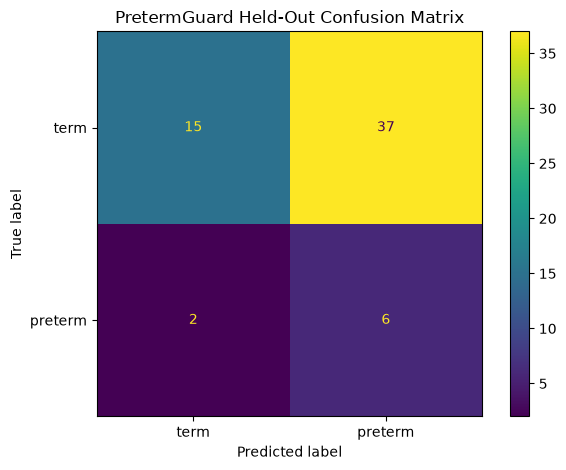

In [21]:
plt.figure(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["term", "preterm"],
    values_format="d",
)
plt.title("PretermGuard Held-Out Confusion Matrix")
plt.tight_layout()
plt.show()

## 20 — Error analysis and bootstrap confidence intervals

In [22]:
heldout_predictions = X_test.copy()
heldout_predictions["true_target"] = y_test
heldout_predictions["predicted_target"] = (
    test_predictions
)
heldout_predictions["preterm_probability"] = (
    calibrated_test_probabilities
)
heldout_predictions["preterm_false_negative"] = (
    (y_test.to_numpy() == 1)
    & (test_predictions == 0)
)
heldout_predictions["term_false_positive"] = (
    (y_test.to_numpy() == 0)
    & (test_predictions == 1)
)

false_negatives = heldout_predictions[
    heldout_predictions[
        "preterm_false_negative"
    ]
].copy()

print(
    "Preterm false negatives:",
    len(false_negatives),
)

display(false_negatives.head(30))

heldout_predictions.to_csv(
    ARTIFACT_DIR / "heldout_predictions.csv",
    index=False,
)
false_negatives.to_csv(
    ARTIFACT_DIR / "preterm_false_negatives.csv",
    index=False,
)


def bootstrap_intervals(
    targets: np.ndarray,
    predictions: np.ndarray,
    probabilities: np.ndarray,
    iterations: int,
) -> dict[str, dict[str, float]]:
    rng = np.random.default_rng(SEED)
    rows = []

    for _ in range(iterations):
        indices = rng.integers(
            0,
            len(targets),
            size=len(targets),
        )

        sampled_targets = targets[indices]

        if len(np.unique(sampled_targets)) < 2:
            continue

        rows.append(
            binary_metrics(
                sampled_targets,
                predictions[indices],
                probabilities[indices],
            )
        )

    frame = pd.DataFrame(rows)
    output = {}

    for metric in [
        "balanced_accuracy",
        "macro_f1",
        "preterm_recall",
        "preterm_precision",
        "roc_auc",
        "average_precision",
    ]:
        output[metric] = {
            "estimate": float(
                unweighted_test_metrics[metric]
            ),
            "lower_95": float(
                frame[metric].quantile(0.025)
            ),
            "upper_95": float(
                frame[metric].quantile(0.975)
            ),
        }

    return output


bootstrap_ci = bootstrap_intervals(
    y_test.to_numpy(),
    test_predictions,
    calibrated_test_probabilities,
    BOOTSTRAP_ITERATIONS,
)

print(json.dumps(bootstrap_ci, indent=2))

with open(
    ARTIFACT_DIR / "bootstrap_intervals.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        bootstrap_ci,
        file,
        indent=2,
    )

Preterm false negatives: 2


,recording_gestation,f008_4_ch1_fmed,f008_4_ch2_fmed,f008_4_ch3_fmed,f008_4_ch1_fpeak,f008_4_ch2_fpeak,f008_4_ch3_fpeak,f008_4_ch1_rms,f008_4_ch2_rms,f008_4_ch3_rms,...,f03_4_ch2_rms,f03_4_ch3_rms,f03_4_ch1_sampen,f03_4_ch2_sampen,f03_4_ch3_sampen,true_target,predicted_target,preterm_probability,preterm_false_negative,term_false_positive
15,24.43,0.1688,0.1729,0.1542,0.1042,0.1063,0.1319,6.2878,4.4666,5.7362,...,2.1690,2.4467,1.094,1.089,1.115,1,0,0.34979,True,False
47,22.29,0.1536,0.1287,0.1273,0.0946,0.0889,0.0889,8.6012,4.5232,6.1606,...,1.6866,2.1784,1.019,1.100,1.088,1,0,0.46543,True,False


{
  "balanced_accuracy": {
    "estimate": 0.5192307692307692,
    "lower_95": 0.3301515151515152,
    "upper_95": 0.6729108391608392
  },
  "macro_f1": {
    "estimate": 0.3350383631713555,
    "lower_95": 0.22157451821465315,
    "upper_95": 0.459253165135518
  },
  "preterm_recall": {
    "estimate": 0.75,
    "lower_95": 0.4,
    "upper_95": 1.0
  },
  "preterm_precision": {
    "estimate": 0.13953488372093023,
    "lower_95": 0.045454545454545456,
    "upper_95": 0.2564102564102564
  },
  "roc_auc": {
    "estimate": 0.4302884615384615,
    "lower_95": 0.23688721361185983,
    "upper_95": 0.6434646464646464
  },
  "average_precision": {
    "estimate": 0.15117195643110276,
    "lower_95": 0.05779752011369658,
    "upper_95": 0.41674008535141394
  }
}


## 21 — Permutation feature importance

In [23]:
importance = permutation_importance(
    primary_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=25 if FAST_MODE else 60,
    random_state=SEED,
    n_jobs=-1,
)

importance_df = (
    pd.DataFrame({
        "feature": MODEL_FEATURES,
        "importance_mean": (
            importance.importances_mean
        ),
        "importance_std": (
            importance.importances_std
        ),
    })
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(importance_df.head(25))

importance_df.to_csv(
    ARTIFACT_DIR / "feature_importance.csv",
    index=False,
)

,feature,importance_mean,importance_std
0,f03_4_ch1_sampen,0.016394,0.012355
1,f03_3_ch3_fmed,0.015356,0.008842
2,f03_4_ch3_sampen,0.013569,0.024291
3,f03_4_ch3_fmed,0.013039,0.007151
4,f03_3_ch1_fmed,0.010914,0.012365
5,f03_3_ch3_fpeak,0.007455,0.013145
6,f03_4_ch1_fmed,0.007043,0.007122
7,f008_4_ch2_rms,0.006944,0.005154
8,f03_4_ch3_fpeak,0.005941,0.023093
9,f03_3_ch1_sampen,0.005804,0.005500


# Part B — Portable EHG model and real external datasets

The portable model uses:

- recording gestational week
- RMS
- median frequency
- peak frequency
- sample entropy

for each of three filtered EHG channels.

These features can be derived from TPEHGT and ICEHG raw EHG records.

## 22 — Raw-EHG feature extractor

In [38]:
def median_frequency(
    signal: np.ndarray,
    sampling_rate: float,
) -> float:
    frequencies, power = periodogram(
        signal,
        fs=sampling_rate,
    )

    valid = (
        np.isfinite(power)
        & (power >= 0)
    )

    frequencies = frequencies[valid]
    power = power[valid]

    total_power = power.sum()

    if (
        len(power) == 0
        or total_power <= 0
    ):
        return np.nan

    cumulative = np.cumsum(power)

    return float(
        frequencies[
            np.searchsorted(
                cumulative,
                total_power / 2,
            )
        ]
    )


def peak_frequency(
    signal: np.ndarray,
    sampling_rate: float,
) -> float:
    frequencies, power = periodogram(
        signal,
        fs=sampling_rate,
    )

    if len(power) == 0:
        return np.nan

    return float(
        frequencies[int(np.argmax(power))]
    )


def safe_sample_entropy(
    signal: np.ndarray,
) -> float:
    signal = np.asarray(
        signal,
        dtype=float,
    )

    signal = signal[
        np.isfinite(signal)
    ]

    if len(signal) < 200:
        return np.nan

    # Keep runtime bounded while retaining signal structure.
    step = max(
        1,
        int(math.ceil(len(signal) / 5000)),
    )
    reduced = signal[::step]

    standard_deviation = float(
        np.std(reduced)
    )

    if standard_deviation <= 0:
        return np.nan

    return float(
        ant.sample_entropy(
            reduced,
            order=3, # Revert to plain int as antropy expects
            tolerance=0.15 * standard_deviation,
            metric='euclidean', # Avoid Numba-specific chebyshev metric
        )
    )


def extract_channel_features(
    signal: np.ndarray,
    sampling_rate: float,
    trim_seconds: float = 180.0,
) -> dict[str, float]:
    signal = np.array(
        signal,
        dtype=float,
        copy=True,
    ).reshape(-1)

    signal = signal[
        np.isfinite(signal)
    ]

    trim_samples = int(
        trim_seconds * sampling_rate
    )

    if len(signal) > 2 * trim_samples + 200:
        signal = signal[
            trim_samples:-trim_samples
        ]

    if len(signal) < 200:
        raise ValueError(
            "EHG channel is too short after trimming."
        )

    signal = signal - np.mean(signal)

    return {
        "rms": float(
            np.sqrt(
                np.mean(
                    np.square(signal)
                )
            )
        ),
        "fmed": median_frequency(
            signal,
            sampling_rate,
        ),
        "fpeak": peak_frequency(
            signal,
            sampling_rate,
        ),
        "sampen": safe_sample_entropy(
            signal
        ),
    }


def choose_filtered_ehg_indices(
    record: wfdb.Record,
) -> list[int]:
    names = [
        str(name).lower()
        for name in record.sig_name
    ]

    selected = []

    for channel_number in [1, 2, 3]:
        candidates = [
            index
            for index, name in enumerate(names)
            if (
                f"s{channel_number}" in name
                and (
                    "0.08" in name
                    or "filtered" in name
                    or "filt" in name
                )
            )
        ]

        if candidates:
            selected.append(candidates[0])

    if len(selected) == 3:
        return selected

    if record.n_sig >= 12:
        return [1, 5, 9]

    if record.n_sig >= 8:
        return [1, 3, 5]

    if record.n_sig >= 3:
        return [0, 1, 2]

    raise ValueError(
        f"Record contains only {record.n_sig} signals."
    )


def parse_recording_gestation(
    comments: list[str],
) -> float:
    patterns = [
        r"gestation duration at the time of recording[^0-9]*(\\d+(?:\\.\\d+)?)",
        r"recording gestation[^0-9]*(\\d+(?:\\.\\d+)?)",
        r"rec(?:ording)?\\.?[\t ]*time[^0-9]*(\\d+(?:\\.\\d+)?)",
    ]

    text = " | ".join(
        str(comment)
        for comment in comments
    ).lower()

    for pattern in patterns:
        match = re.search(
            pattern,
            text,
            flags=re.IGNORECASE,
        )

        if match:
            return float(match.group(1))

    return np.nan


def extract_portable_record_features(
    record: wfdb.Record,
    recording_gestation_fallback: float = np.nan,
) -> dict[str, float]:
    indices = choose_filtered_ehg_indices(
        record
    )

    output = {}

    for channel_number, signal_index in enumerate(
        indices,
        start=1,
    ):
        channel_features = extract_channel_features(
            record.p_signal[:, signal_index],
            float(record.fs),
        )

        for feature_name, value in channel_features.items():
            output[
                f"f008_4_ch{channel_number}_{feature_name}"
            ] = value

    recording_gestation = parse_recording_gestation(
        list(record.comments or [])
    )

    if pd.isna(recording_gestation):
        recording_gestation = (
            recording_gestation_fallback
        )

    output["recording_gestation"] = (
        recording_gestation
    )

    return output

## 23 — Raw extractor unit test

In [40]:
synthetic_time = np.arange(
    0,
    1800,
    1 / 20,
)

synthetic_signal = (
    0.5 * np.sin(
        2 * np.pi * 0.4 * synthetic_time
    )
    + 0.1 * np.sin(
        2 * np.pi * 1.0 * synthetic_time
    )
)

synthetic_features = extract_channel_features(
    synthetic_signal,
    sampling_rate=20.0,
)

assert set(synthetic_features) == {
    "rms",
    "fmed",
    "fpeak",
    "sampen",
}
assert np.isfinite(
    synthetic_features["rms"]
)

print("Raw EHG feature-extraction test passed.")
print(synthetic_features)

Raw EHG feature-extraction test passed.
{'rms': 0.3605551275463989, 'fmed': 0.4, 'fpeak': 0.4, 'sampen': -0.0}


## 24 — Train the portable primary model

In [41]:
X_portable_all = primary_data[
    PORTABLE_FEATURES
].copy()

X_portable_train = X_portable_all.iloc[
    train_indices
].reset_index(drop=True)

X_portable_test = X_portable_all.iloc[
    test_indices
].reset_index(drop=True)

PORTABLE_CANDIDATES = {
    name: clone(model)
    for name, model
    in CANDIDATE_MODELS.items()
}

portable_rows = []

for name, estimator in PORTABLE_CANDIDATES.items():
    report = evaluate_cv(
        estimator,
        X_portable_train,
        y_train,
        CV_SPLITS_LIST,
    )

    portable_rows.append({
        "model": name,
        "mean_safety": report["safety"].mean(),
        "mean_average_precision": (
            report["average_precision"].mean()
        ),
        "mean_preterm_recall": (
            report["preterm_recall"].mean()
        ),
        "mean_macro_f1": report["macro_f1"].mean(),
    })

portable_benchmark = (
    pd.DataFrame(portable_rows)
    .sort_values(
        ["mean_safety", "mean_average_precision"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(portable_benchmark)

portable_family = str(
    portable_benchmark.iloc[0]["model"]
)
portable_estimator = clone(
    PORTABLE_CANDIDATES[
        portable_family
    ]
)

portable_oof_raw = generate_oof_probabilities(
    portable_estimator,
    X_portable_train,
    y_train,
    CV_SPLITS_LIST,
)

portable_calibrator = fit_platt_calibrator(
    portable_oof_raw,
    y_train,
)

portable_oof_calibrated = apply_calibrator(
    portable_calibrator,
    portable_oof_raw,
)

PORTABLE_THRESHOLD, portable_threshold_table = (
    select_preterm_threshold(
        portable_oof_calibrated,
        y_train,
    )
)

portable_model = fit_weighted_model(
    portable_estimator,
    X_portable_train,
    y_train,
)

portable_test_raw = portable_model.predict_proba(
    X_portable_test
)[:, 1]

portable_test_probability = apply_calibrator(
    portable_calibrator,
    portable_test_raw,
)

portable_test_prediction = (
    portable_test_probability
    >= PORTABLE_THRESHOLD
).astype(int)

portable_internal_metrics = binary_metrics(
    y_test,
    portable_test_prediction,
    portable_test_probability,
)

print("Portable family:", portable_family)
print("Portable threshold:", PORTABLE_THRESHOLD)
print(
    json.dumps(
        portable_internal_metrics,
        indent=2,
    )
)

,model,mean_safety,mean_average_precision,mean_preterm_recall,mean_macro_f1
0,logistic_regression,0.594679,0.656653,0.566667,0.635858
1,xgboost,0.271344,0.626413,0.133333,0.443948
2,random_forest,0.182718,0.611096,0.033333,0.353730
3,extra_trees,0.157710,0.671967,0.000000,0.332267


Portable family: logistic_regression
Portable threshold: 0.43
{
  "safety": 0.7059866630598728,
  "accuracy": 0.38333333333333336,
  "balanced_accuracy": 0.5913461538461539,
  "macro_f1": 0.3691389599317988,
  "preterm_recall": 0.875,
  "preterm_precision": 0.16279069767441862,
  "roc_auc": 0.4423076923076923,
  "average_precision": 0.13166372018085643,
  "log_loss": 0.7190763312157877
}


## 25 — Automatic TPEHGT external validation

In [42]:
TPEHGT_BASE_URL = (
    "https://physionet.org/files/"
    "tpehgt/1.0.0"
)

tpehgt_rows = []
tpehgt_errors = []

try:
    tpehgt_records = read_physionet_records(
        TPEHGT_BASE_URL
    )

    for record_name in tpehgt_records:
        basename = Path(record_name).name
        lower_name = basename.lower()

        if "_n" in lower_name:
            continue
        if "_p" in lower_name:
            target = 1
        elif "_t" in lower_name:
            target = 0
        else:
            continue

        try:
            record = wfdb.rdrecord(
                record_name,
                pn_dir="tpehgt/1.0.0",
            )

            row = extract_portable_record_features(
                record
            )
            row.update({
                "record": basename,
                "target": target,
                "dataset_source": "tpehgt",
            })
            tpehgt_rows.append(row)

        except Exception as error:
            tpehgt_errors.append({
                "record": record_name,
                "error": repr(error),
            })

    tpehgt_data = pd.DataFrame(
        tpehgt_rows
    )

    if (
        len(tpehgt_data) >= 20
        and tpehgt_data["target"].nunique() == 2
    ):
        tpehgt_raw_probability = (
            portable_model.predict_proba(
                tpehgt_data[
                    PORTABLE_FEATURES
                ]
            )[:, 1]
        )

        tpehgt_probability = apply_calibrator(
            portable_calibrator,
            tpehgt_raw_probability,
        )

        tpehgt_prediction = (
            tpehgt_probability
            >= PORTABLE_THRESHOLD
        ).astype(int)

        tpehgt_metrics = binary_metrics(
            tpehgt_data["target"],
            tpehgt_prediction,
            tpehgt_probability,
        )

        EXTERNAL_STAGE_STATUS["tpehgt"] = {
            "status": "success",
            "usable_records": int(
                len(tpehgt_data)
            ),
            "failed_records": int(
                len(tpehgt_errors)
            ),
            "metrics": tpehgt_metrics,
        }
    else:
        tpehgt_metrics = {}
        EXTERNAL_STAGE_STATUS["tpehgt"] = {
            "status": "insufficient_usable_records",
            "usable_records": int(
                len(tpehgt_data)
            ),
            "failed_records": int(
                len(tpehgt_errors)
            ),
        }

except Exception as error:
    tpehgt_data = pd.DataFrame()
    tpehgt_metrics = {}
    EXTERNAL_STAGE_STATUS["tpehgt"] = {
        "status": "skipped_after_error",
        "error": repr(error),
    }

print(
    json.dumps(
        EXTERNAL_STAGE_STATUS["tpehgt"],
        indent=2,
    )
)

tpehgt_data.to_parquet(
    PROCESSED_DIR / "tpehgt_external_features.parquet",
    index=False,
)

pd.DataFrame(
    tpehgt_errors,
    columns=["record", "error"],
).to_csv(
    ARTIFACT_DIR / "tpehgt_processing_errors.csv",
    index=False,
)

{
  "status": "success",
  "usable_records": 26,
  "failed_records": 0,
  "metrics": {
    "safety": 0.15833333333333333,
    "accuracy": 0.5,
    "balanced_accuracy": 0.5,
    "macro_f1": 0.3333333333333333,
    "preterm_recall": 0.0,
    "preterm_precision": 0.0,
    "roc_auc": 0.21893491124260353,
    "average_precision": 0.37469897345315406,
    "log_loss": 1.595393200976082
  }
}


## 26 — Automatic ICEHG term-delivery robustness test

In [43]:
ICEHG_BASE_URL = (
    "https://physionet.org/files/"
    "icehg-ds/1.0.1"
)

ICEHG_SUBSETS = [
    "early_induced",
    "later_induced",
    "early_cesarean",
    "later_cesarean",
    "early_induced-cesarean",
    "later_induced-cesarean",
]

icehg_rows = []
icehg_errors = []

try:
    for subset in ICEHG_SUBSETS:
        subset_url = (
            f"{ICEHG_BASE_URL}/{subset}"
        )

        try:
            subset_records = read_physionet_records(
                subset_url
            )
        except Exception as error:
            icehg_errors.append({
                "record": subset,
                "error": (
                    "RECORDS download failed: "
                    + repr(error)
                ),
            })
            continue

        fallback_week = (
            23.0
            if subset.startswith("early")
            else 31.0
        )

        for record_name in subset_records:
            try:
                record = wfdb.rdrecord(
                    record_name,
                    pn_dir=(
                        "icehg-ds/1.0.1/"
                        + subset
                    ),
                )

                row = extract_portable_record_features(
                    record,
                    recording_gestation_fallback=(
                        fallback_week
                    ),
                )

                row.update({
                    "record": Path(record_name).name,
                    "subset": subset,
                    "target": 0,
                    "dataset_source": "icehg",
                })
                icehg_rows.append(row)

            except Exception as error:
                icehg_errors.append({
                    "record": (
                        f"{subset}/{record_name}"
                    ),
                    "error": repr(error),
                })

    icehg_data = pd.DataFrame(
        icehg_rows
    )

    if len(icehg_data) >= 50:
        icehg_raw_probability = (
            portable_model.predict_proba(
                icehg_data[
                    PORTABLE_FEATURES
                ]
            )[:, 1]
        )

        icehg_probability = apply_calibrator(
            portable_calibrator,
            icehg_raw_probability,
        )

        icehg_prediction = (
            icehg_probability
            >= PORTABLE_THRESHOLD
        ).astype(int)

        false_positive_rate = float(
            np.mean(icehg_prediction == 1)
        )

        icehg_metrics = {
            "usable_term_records": int(
                len(icehg_data)
            ),
            "false_positive_records": int(
                np.sum(icehg_prediction == 1)
            ),
            "term_specificity": float(
                1 - false_positive_rate
            ),
            "false_positive_rate": (
                false_positive_rate
            ),
            "mean_preterm_probability": float(
                np.mean(icehg_probability)
            ),
        }

        EXTERNAL_STAGE_STATUS["icehg"] = {
            "status": "success",
            "failed_records": int(
                len(icehg_errors)
            ),
            "metrics": icehg_metrics,
        }
    else:
        icehg_metrics = {}
        EXTERNAL_STAGE_STATUS["icehg"] = {
            "status": "insufficient_usable_records",
            "usable_records": int(
                len(icehg_data)
            ),
            "failed_records": int(
                len(icehg_errors)
            ),
        }

except Exception as error:
    icehg_data = pd.DataFrame()
    icehg_metrics = {}
    EXTERNAL_STAGE_STATUS["icehg"] = {
        "status": "skipped_after_error",
        "error": repr(error),
    }

print(
    json.dumps(
        EXTERNAL_STAGE_STATUS["icehg"],
        indent=2,
    )
)

icehg_data.to_parquet(
    PROCESSED_DIR / "icehg_robustness_features.parquet",
    index=False,
)

pd.DataFrame(
    icehg_errors,
    columns=["record", "error"],
).to_csv(
    ARTIFACT_DIR / "icehg_processing_errors.csv",
    index=False,
)

{
  "status": "insufficient_usable_records",
  "usable_records": 0,
  "failed_records": 6
}


## 27 — Research acceptance gates

In [44]:
PRIMARY_ACCEPTANCE_CHECKS = {
    "preterm_recall_at_least_0_85": (
        weighted_test_metrics["preterm_recall"]
        >= 0.85
    ),
    "balanced_accuracy_at_least_0_70": (
        weighted_test_metrics[
            "balanced_accuracy"
        ] >= 0.70
    ),
    "average_precision_at_least_0_45": (
        weighted_test_metrics[
            "average_precision"
        ] >= 0.45
    ),
    "preterm_precision_at_least_0_35": (
        weighted_test_metrics[
            "preterm_precision"
        ] >= 0.35
    ),
}

external_tpehgt_pass = bool(
    tpehgt_metrics
    and tpehgt_metrics.get(
        "balanced_accuracy",
        0.0,
    ) >= 0.60
    and tpehgt_metrics.get(
        "preterm_recall",
        0.0,
    ) >= 0.70
)

icehg_robustness_pass = bool(
    icehg_metrics
    and icehg_metrics.get(
        "term_specificity",
        0.0,
    ) >= 0.70
)

PRIMARY_DEPLOYMENT_STATUS = (
    "research_candidate_passed_internal_gates"
    if all(
        PRIMARY_ACCEPTANCE_CHECKS.values()
    )
    else "research_only_failed_internal_gates"
)

OVERALL_VALIDATION_STATUS = (
    "research_candidate_with_external_support"
    if (
        all(
            PRIMARY_ACCEPTANCE_CHECKS.values()
        )
        and external_tpehgt_pass
        and icehg_robustness_pass
    )
    else "research_only_external_validation_incomplete_or_failed"
)

acceptance_report = {
    "primary_checks": (
        PRIMARY_ACCEPTANCE_CHECKS
    ),
    "tpehgt_external_pass": (
        external_tpehgt_pass
    ),
    "icehg_robustness_pass": (
        icehg_robustness_pass
    ),
    "primary_status": (
        PRIMARY_DEPLOYMENT_STATUS
    ),
    "overall_status": (
        OVERALL_VALIDATION_STATUS
    ),
}

print(
    json.dumps(
        acceptance_report,
        indent=2,
    )
)

{
  "primary_checks": {
    "preterm_recall_at_least_0_85": false,
    "balanced_accuracy_at_least_0_70": false,
    "average_precision_at_least_0_45": true,
    "preterm_precision_at_least_0_35": true
  },
  "tpehgt_external_pass": false,
  "icehg_robustness_pass": false,
  "primary_status": "research_only_failed_internal_gates",
  "overall_status": "research_only_external_validation_incomplete_or_failed"
}


## 28 — Refit final full and portable models using all primary records

In [45]:
full_splitter = StratifiedGroupKFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=SEED,
)

full_splits = list(
    full_splitter.split(
        X_all,
        y_all,
        groups=groups_all,
    )
)

full_oof_raw = generate_oof_probabilities(
    best_estimator,
    X_all,
    y_all,
    full_splits,
)

final_calibrator = fit_platt_calibrator(
    full_oof_raw,
    y_all,
)

full_oof_calibrated = apply_calibrator(
    final_calibrator,
    full_oof_raw,
)

FINAL_THRESHOLD, _ = select_preterm_threshold(
    full_oof_calibrated,
    y_all,
)

final_full_model = fit_weighted_model(
    best_estimator,
    X_all,
    y_all,
)


portable_full_splits = list(
    full_splitter.split(
        X_portable_all,
        y_all,
        groups=groups_all,
    )
)

portable_full_oof_raw = (
    generate_oof_probabilities(
        portable_estimator,
        X_portable_all,
        y_all,
        portable_full_splits,
    )
)

final_portable_calibrator = (
    fit_platt_calibrator(
        portable_full_oof_raw,
        y_all,
    )
)

portable_full_oof_calibrated = (
    apply_calibrator(
        final_portable_calibrator,
        portable_full_oof_raw,
    )
)

FINAL_PORTABLE_THRESHOLD, _ = (
    select_preterm_threshold(
        portable_full_oof_calibrated,
        y_all,
    )
)

final_portable_model = fit_weighted_model(
    portable_estimator,
    X_portable_all,
    y_all,
)

print("Final full threshold:", FINAL_THRESHOLD)
print(
    "Final portable threshold:",
    FINAL_PORTABLE_THRESHOLD,
)

Final full threshold: 0.49
Final portable threshold: 0.46


## 29 — Save bundles, model card and governance artifacts

In [46]:
trained_at = datetime.now(
    timezone.utc
).isoformat()

training_quantiles = {
    feature: {
        "q005": float(
            X_portable_all[
                feature
            ].quantile(0.005)
        ),
        "q995": float(
            X_portable_all[
                feature
            ].quantile(0.995)
        ),
        "median": float(
            X_portable_all[
                feature
            ].median()
        ),
    }
    for feature in PORTABLE_FEATURES
}

full_bundle = {
    "model_name": "PretermGuard-Full",
    "model_version": MODEL_VERSION,
    "trained_at_utc": trained_at,
    "model": final_full_model,
    "calibrator": final_calibrator,
    "threshold": FINAL_THRESHOLD,
    "features": MODEL_FEATURES,
    "target_definition": TARGET_DEFINITION,
    "selected_model_family": best_family,
    "selected_parameters": best_parameters,
    "primary_status": PRIMARY_DEPLOYMENT_STATUS,
}

portable_bundle = {
    "model_name": "PretermGuard-Portable",
    "model_version": MODEL_VERSION,
    "trained_at_utc": trained_at,
    "model": final_portable_model,
    "calibrator": final_portable_calibrator,
    "threshold": FINAL_PORTABLE_THRESHOLD,
    "features": PORTABLE_FEATURES,
    "target_definition": TARGET_DEFINITION,
    "selected_model_family": portable_family,
    "training_quantiles": training_quantiles,
    "sanity_ranges": {
        "recording_gestation": [10, 40],
        "rms": [0, 1000],
        "fmed": [0, 10],
        "fpeak": [0, 10],
        "sampen": [0, 10],
    },
    "primary_status": PRIMARY_DEPLOYMENT_STATUS,
    "overall_validation_status": (
        OVERALL_VALIDATION_STATUS
    ),
}

full_bundle_path = (
    ARTIFACT_DIR
    / "pretermguard_full_bundle.joblib"
)
portable_bundle_path = (
    ARTIFACT_DIR
    / "pretermguard_portable_bundle.joblib"
)

joblib.dump(
    full_bundle,
    full_bundle_path,
    compress=3,
)
joblib.dump(
    portable_bundle,
    portable_bundle_path,
    compress=3,
)

bundle_hashes = {
    "full_sha256": hashlib.sha256(
        full_bundle_path.read_bytes()
    ).hexdigest(),
    "portable_sha256": hashlib.sha256(
        portable_bundle_path.read_bytes()
    ).hexdigest(),
}

model_card = {
    "model_name": "PretermGuard",
    "version": MODEL_VERSION,
    "created_at_utc": trained_at,
    "datasets": DATASET_REGISTRY,
    "target_definition": (
        "Dataset-defined preterm outcome; "
        "delivery outcome fields are excluded from features."
    ),
    "intended_use": (
        "Research screening support using EHG summary features "
        "obtained during antenatal assessment."
    ),
    "not_intended_for": [
        "Autonomous diagnosis of preterm labour",
        "Treatment, admission, steroid, tocolysis or delivery decisions",
        "Home use without validated EHG acquisition",
        "Use on a new device without prospective validation",
    ],
    "primary_training_rows": int(
        len(primary_data)
    ),
    "preterm_training_rows": int(
        primary_data["target"].sum()
    ),
    "full_model_features": MODEL_FEATURES,
    "portable_features": PORTABLE_FEATURES,
    "selected_full_family": best_family,
    "selected_full_parameters": (
        best_parameters
    ),
    "selected_portable_family": (
        portable_family
    ),
    "heldout_unweighted_metrics": (
        unweighted_test_metrics
    ),
    "heldout_weighted_metrics": (
        weighted_test_metrics
    ),
    "bootstrap_intervals": bootstrap_ci,
    "tpehgt_external_metrics": (
        tpehgt_metrics
    ),
    "icehg_robustness_metrics": (
        icehg_metrics
    ),
    "acceptance_report": (
        acceptance_report
    ),
    "external_stage_status": (
        EXTERNAL_STAGE_STATUS
    ),
    "bundle_hashes": bundle_hashes,
    "limitations": [
        "The primary dataset contains only 38 preterm outcomes.",
        "The main primary cohort comes from one Slovenian centre.",
        "TPEHGT external validation is small.",
        "ICEHG assesses term delivery-mode false positives, not preterm sensitivity.",
        "The portable feature extraction may differ from official TPEHGDB features.",
        "Prospective Pakistani validation and ethics governance are required.",
    ],
}

with open(
    ARTIFACT_DIR / "model_card.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        model_card,
        file,
        indent=2,
        default=str,
    )

with open(
    ARTIFACT_DIR / "external_stage_status.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        EXTERNAL_STAGE_STATUS,
        file,
        indent=2,
        default=str,
    )

with open(
    ARTIFACT_DIR / "acceptance_report.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        acceptance_report,
        file,
        indent=2,
    )

print("Bundle hashes:")
print(json.dumps(bundle_hashes, indent=2))

Bundle hashes:
{
  "full_sha256": "849e83f7977415ce8da4c2a56fb3fba072ec6622f3b7e0535f50076c07e06916",
  "portable_sha256": "7065967e152c387ed8440659ca643784ea191e4afa1a12f164a96d530dbf2719"
}


## 30 — Portable inference module

In [47]:
%%writefile /content/pretermguard_model_3/artifacts/inference.py
from __future__ import annotations

from pathlib import Path
from typing import Any, Mapping

import joblib
import numpy as np
import pandas as pd

BUNDLE = joblib.load(
    Path(__file__).with_name(
        "pretermguard_portable_bundle.joblib"
    )
)


def probability_to_logit(
    probability: float,
) -> np.ndarray:
    value = float(
        np.clip(
            probability,
            1e-6,
            1 - 1e-6,
        )
    )

    return np.asarray(
        [[
            np.log(
                value / (1 - value)
            )
        ]],
        dtype=float,
    )


def predict_preterm_risk(
    measurements: Mapping[
        str,
        float | int | None,
    ],
) -> dict[str, Any]:
    required = list(
        BUNDLE["features"]
    )

    missing = [
        feature
        for feature in required
        if measurements.get(feature) is None
    ]

    if missing:
        return {
            "status": "invalid_input",
            "missing_features": missing,
            "required_features": required,
        }

    try:
        numeric = {
            feature: float(
                measurements[feature]
            )
            for feature in required
        }
    except (TypeError, ValueError):
        return {
            "status": "invalid_input",
            "message": (
                "All EHG summary features must be numeric."
            ),
        }

    invalid = []

    for feature, value in numeric.items():
        if feature == "recording_gestation":
            lower, upper = BUNDLE[
                "sanity_ranges"
            ]["recording_gestation"]
        else:
            feature_type = feature.rsplit(
                "_",
                1,
            )[-1]
            lower, upper = BUNDLE[
                "sanity_ranges"
            ][feature_type]

        if not lower <= value <= upper:
            invalid.append({
                "feature": feature,
                "value": value,
                "allowed_range": [
                    lower,
                    upper,
                ],
            })

    if invalid:
        return {
            "status": "invalid_input",
            "out_of_sanity_range": invalid,
        }

    frame = pd.DataFrame(
        [numeric],
        columns=required,
    )

    raw_probability = float(
        BUNDLE["model"]
        .predict_proba(frame)[0, 1]
    )

    calibrated_probability = float(
        BUNDLE["calibrator"]
        .predict_proba(
            probability_to_logit(
                raw_probability
            )
        )[0, 1]
    )

    threshold = float(
        BUNDLE["threshold"]
    )

    decision = (
        "preterm_risk_flag"
        if calibrated_probability
        >= threshold
        else "term_pattern"
    )

    ood_warnings = []

    for feature, value in numeric.items():
        quantiles = BUNDLE[
            "training_quantiles"
        ][feature]

        if (
            value < quantiles["q005"]
            or value > quantiles["q995"]
        ):
            ood_warnings.append({
                "feature": feature,
                "value": value,
                "training_central_range": [
                    quantiles["q005"],
                    quantiles["q995"],
                ],
            })

    return {
        "status": "ok",
        "model": BUNDLE["model_name"],
        "version": BUNDLE["model_version"],
        "deployment_status": BUNDLE[
            "overall_validation_status"
        ],
        "decision": decision,
        "preterm_probability": (
            calibrated_probability
        ),
        "threshold": threshold,
        "clinical_review_required": (
            decision == "preterm_risk_flag"
            or bool(ood_warnings)
        ),
        "out_of_distribution_warnings": (
            ood_warnings
        ),
        "clinical_notice": (
            "Research screening result only. "
            "It is not a diagnosis of preterm labour."
        ),
    }

Writing /content/pretermguard_model_3/artifacts/inference.py


## 31 — Inference smoke tests

In [48]:
import sys

sys.path.insert(
    0,
    str(ARTIFACT_DIR.resolve()),
)

from inference import predict_preterm_risk

example_payload = (
    X_portable_all
    .median()
    .astype(float)
    .to_dict()
)

valid_result = predict_preterm_risk(
    example_payload
)

missing_result = predict_preterm_risk({
    "recording_gestation": 25,
})

invalid_result = predict_preterm_risk({
    **example_payload,
    "recording_gestation": 100,
})

assert valid_result["status"] == "ok"
assert (
    0
    <= valid_result["preterm_probability"]
    <= 1
)
assert missing_result["status"] == (
    "invalid_input"
)
assert invalid_result["status"] == (
    "invalid_input"
)

print("Inference smoke tests passed.")
print(
    json.dumps(
        valid_result,
        indent=2,
    )
)

Inference smoke tests passed.
{
  "status": "ok",
  "model": "PretermGuard-Portable",
  "version": "1.0.0",
  "deployment_status": "research_only_external_validation_incomplete_or_failed",
  "decision": "preterm_risk_flag",
  "preterm_probability": 0.5020364066594617,
  "threshold": 0.46,
  "clinical_review_required": true,
  "out_of_distribution_warnings": [],
  "clinical_notice": "Research screening result only. It is not a diagnosis of preterm labour."
}


## 32 — FastAPI service

In [49]:
%%writefile /content/pretermguard_model_3/artifacts/app.py
from __future__ import annotations

from typing import Any

from fastapi import FastAPI
from pydantic import BaseModel, ConfigDict, Field

from inference import predict_preterm_risk

app = FastAPI(
    title="MaaHifazat PretermGuard API",
    version="1.0.0",
)


class EHGFeatures(BaseModel):
    model_config = ConfigDict(
        extra="forbid"
    )

    recording_gestation: float = Field(
        ge=10,
        le=40,
    )

    f008_4_ch1_rms: float = Field(ge=0, le=1000)
    f008_4_ch1_fmed: float = Field(ge=0, le=10)
    f008_4_ch1_fpeak: float = Field(ge=0, le=10)
    f008_4_ch1_sampen: float = Field(ge=0, le=10)

    f008_4_ch2_rms: float = Field(ge=0, le=1000)
    f008_4_ch2_fmed: float = Field(ge=0, le=10)
    f008_4_ch2_fpeak: float = Field(ge=0, le=10)
    f008_4_ch2_sampen: float = Field(ge=0, le=10)

    f008_4_ch3_rms: float = Field(ge=0, le=1000)
    f008_4_ch3_fmed: float = Field(ge=0, le=10)
    f008_4_ch3_fpeak: float = Field(ge=0, le=10)
    f008_4_ch3_sampen: float = Field(ge=0, le=10)


class PredictionRequest(BaseModel):
    model_config = ConfigDict(
        extra="forbid"
    )

    measurements: EHGFeatures


@app.get("/health")
def health() -> dict[str, str]:
    return {
        "status": "healthy",
        "model": "PretermGuard",
        "version": "1.0.0",
    }


@app.post("/predict")
def predict(
    request: PredictionRequest,
) -> dict[str, Any]:
    return predict_preterm_risk(
        request.measurements.model_dump()
    )

Writing /content/pretermguard_model_3/artifacts/app.py


## 33 — LangGraph-ready deterministic node

In [50]:
%%writefile /content/pretermguard_model_3/artifacts/langgraph_tool.py
from __future__ import annotations

from typing import Any, TypedDict

from inference import predict_preterm_risk


class PretermGuardState(
    TypedDict,
    total=False,
):
    ehg_features: dict[str, float]
    pretermguard_result: dict[str, Any]


def pretermguard_screening_node(
    state: PretermGuardState,
) -> PretermGuardState:
    """
    Deterministic research screening node.

    It does not diagnose, prescribe, or replace a clinician.
    """
    result = predict_preterm_risk(
        state.get(
            "ehg_features",
            {},
        )
    )

    return {
        **state,
        "pretermguard_result": result,
    }

Writing /content/pretermguard_model_3/artifacts/langgraph_tool.py


## 34 — Package and download artifacts

In [51]:
requirements_text = f'''pandas=={pd.__version__}
numpy=={np.__version__}
scikit-learn=={sklearn.__version__}
xgboost=={xgboost.__version__}
joblib=={joblib.__version__}
fastapi
uvicorn
pydantic
'''

(
    ARTIFACT_DIR
    / "requirements.txt"
).write_text(
    requirements_text,
    encoding="utf-8",
)

(
    ARTIFACT_DIR
    / "README.md"
).write_text(
    '''# MaaHifazat PretermGuard

## Model

Preterm birth research-screening model using EHG summary features.

## Data architecture

- TPEHGDB: primary supervised model
- TPEHGT: strict external validation
- ICEHG: term induced/cesarean false-positive stress test

## API

```bash
pip install -r requirements.txt
uvicorn app:app --host 0.0.0.0 --port 8000
```

## Warning

Research and hackathon prototype only. This is not a diagnosis of
preterm labour and cannot replace obstetric assessment.
''',
    encoding="utf-8",
)

archive_path = shutil.make_archive(
    "/content/PretermGuard_MODEL_3_Artifacts",
    "zip",
    root_dir=ARTIFACT_DIR,
)

print("Created:", archive_path)

try:
    from google.colab import files
    files.download(archive_path)
except ImportError:
    print("Artifacts:", ARTIFACT_DIR)

Created: /content/PretermGuard_MODEL_3_Artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Final review checklist

Do not accept the model only because the notebook completed.

Review:

- held-out preterm recall and precision;
- average precision and balanced accuracy;
- bootstrap confidence intervals;
- every preterm false negative;
- TPEHGT strict external-validation results;
- ICEHG term specificity;
- `overall_validation_status`;
- prospective Pakistani device/hospital validation needs.

Correct description:

> PretermGuard is a TPEHGDB-trained preterm-birth screening model with
> independent TPEHGT validation and ICEHG delivery-mode robustness testing.